## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
%matplotlib inline

## Load Dataset

In [4]:
df = pd.read_csv('carData.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## Initial Data Inspection

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:", df.columns.tolist())

Dataset Shape: (4340, 8)

Column Names: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


In [6]:
print("Missing Values:\n", df.isnull().sum())

print("\nNumber of Duplicate Rows:", df.duplicated().sum())

df.describe()

Missing Values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Number of Duplicate Rows: 763


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## Data Cleaning

In [7]:
print("Shape before cleaning:", df.shape)

df = df.drop_duplicates()

df = df.dropna()

print("Shape after cleaning:", df.shape)

Shape before cleaning: (4340, 8)
Shape after cleaning: (3577, 8)


## Clean Categorical Columns

In [9]:

categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

fuel: ['Petrol' 'Diesel' 'Cng' 'Lpg' 'Electric']
seller_type: ['Individual' 'Dealer' 'Trustmark Dealer']
transmission: ['Manual' 'Automatic']
owner: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


## Feature Engineering

In [11]:
current_year = df['year'].max()
df['Car_Age'] = current_year - df['year']
df['Brand'] = df['name'].str.split().str[0].str.title()
df = df.drop(['name', 'year'], axis=1)
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,60000,70000,Petrol,Individual,Manual,First Owner,13,Maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,13,Maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,8,Hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,3,Datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,6,Honda


## Exploratory Data Analysis: Selling Price Distribution

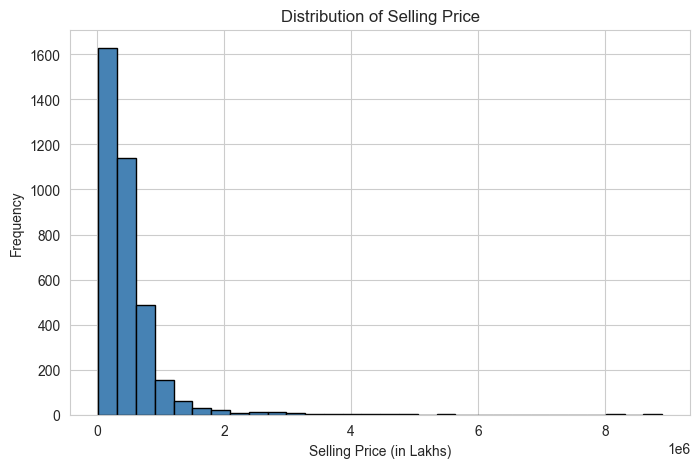

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df['selling_price'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.savefig('SP_VS_Freq.png')
plt.show()

## Selling Price vs Fuel Type

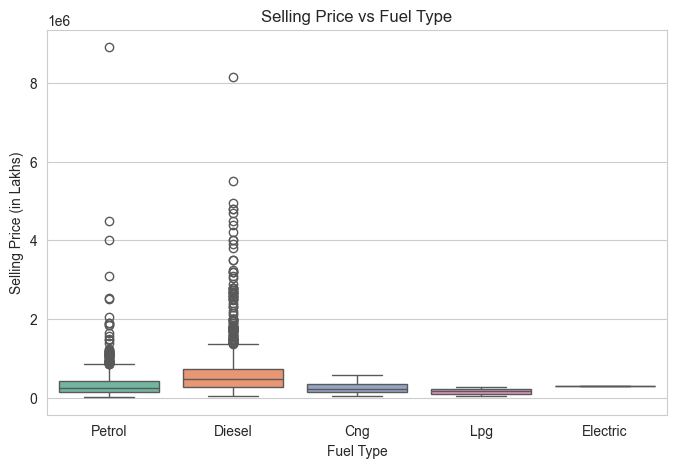

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='fuel', y='selling_price', data=df, hue='fuel', palette='Set2', legend=False)
plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.savefig('SP_VS_FuelType.png')
plt.show()

## Selling Price vs Car Age

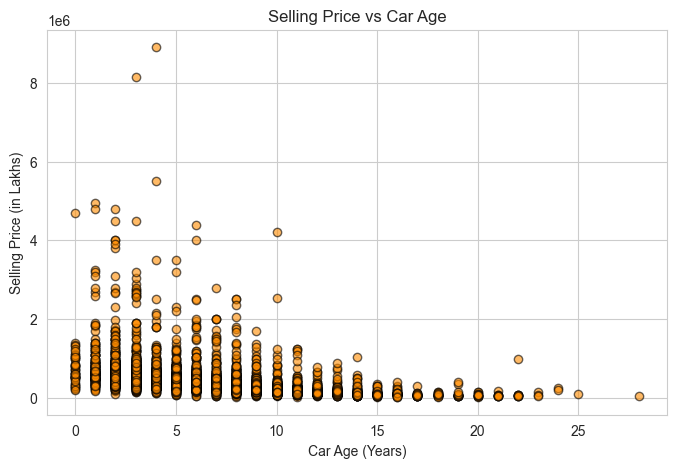

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Car_Age'], df['selling_price'], alpha=0.6, color='darkorange', edgecolor='black')
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (in Lakhs)')
plt.savefig('SP_Vs_Car_Age.png')
plt.show()

## Correlation Heatmap

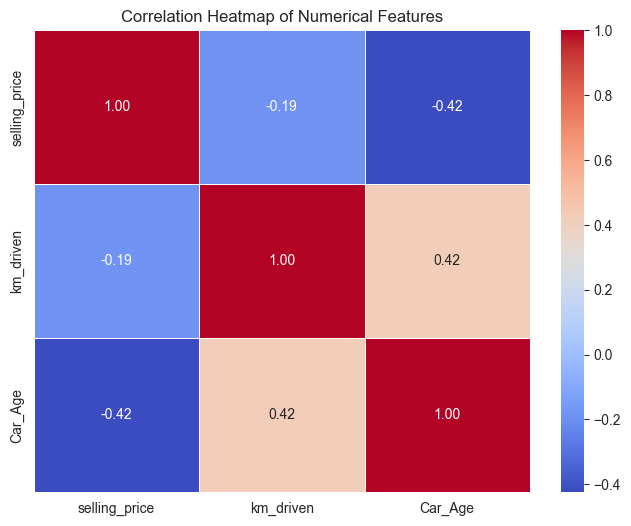

In [20]:
plt.figure(figsize=(8, 6))
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('heatmap.png')
plt.show()

## Encode Categorical Variables

In [31]:
# One-Hot Encoding categorical columns
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner','Brand']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,selling_price,km_driven,Car_Age,fuel_Diesel,fuel_Electric,fuel_Lpg,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,Brand_Mg,Brand_Mitsubishi,Brand_Nissan,Brand_Opelcorsa,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,60000,70000,13,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,135000,50000,13,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,600000,100000,8,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,250000,46000,3,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,450000,141000,6,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


In [32]:
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

## Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
print(X)


      km_driven  Car_Age  fuel_Diesel  fuel_Electric  fuel_Lpg  fuel_Petrol  \
0         70000       13        False          False     False         True   
1         50000       13        False          False     False         True   
2        100000        8         True          False     False        False   
3         46000        3        False          False     False         True   
4        141000        6         True          False     False        False   
...         ...      ...          ...            ...       ...          ...   
4335      80000        6         True          False     False        False   
4336      80000        6         True          False     False        False   
4337      83000       11        False          False     False         True   
4338      90000        4         True          False     False        False   
4339      40000        4        False          False     False         True   

      seller_type_Individual  seller_type_Trustmark

In [35]:
print(y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 3577, dtype: int64


## Model 1: Linear Regression

In [36]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


## Evaluate Linear Regression

In [38]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)


print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R² Score:", round(r2_lr, 2))

MAE: 180194.99
RMSE: 385606.09
R² Score: 0.54


## Model 2: Random Forest Regressor

In [39]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)



## Evaluate Random Forest

In [40]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R² Score:", round(r2_rf, 2))

MAE: 158918.38
RMSE: 365567.41
R² Score: 0.59


## Compare Both Models

In [41]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [round(mae_lr, 2), round(mae_rf, 2)],
    'RMSE': [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R2 Score': [round(r2_lr, 2), round(r2_rf, 2)]
})

print(comparison_df)

best_model_name = comparison_df.loc[comparison_df['R2 Score'].idxmax(), 'Model']
print("\nBest performing model based on R² Score:", best_model_name)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  180194.99  385606.09      0.54
1      Random Forest  158918.38  365567.41      0.59

Best performing model based on R² Score: Random Forest


## Feature Importance

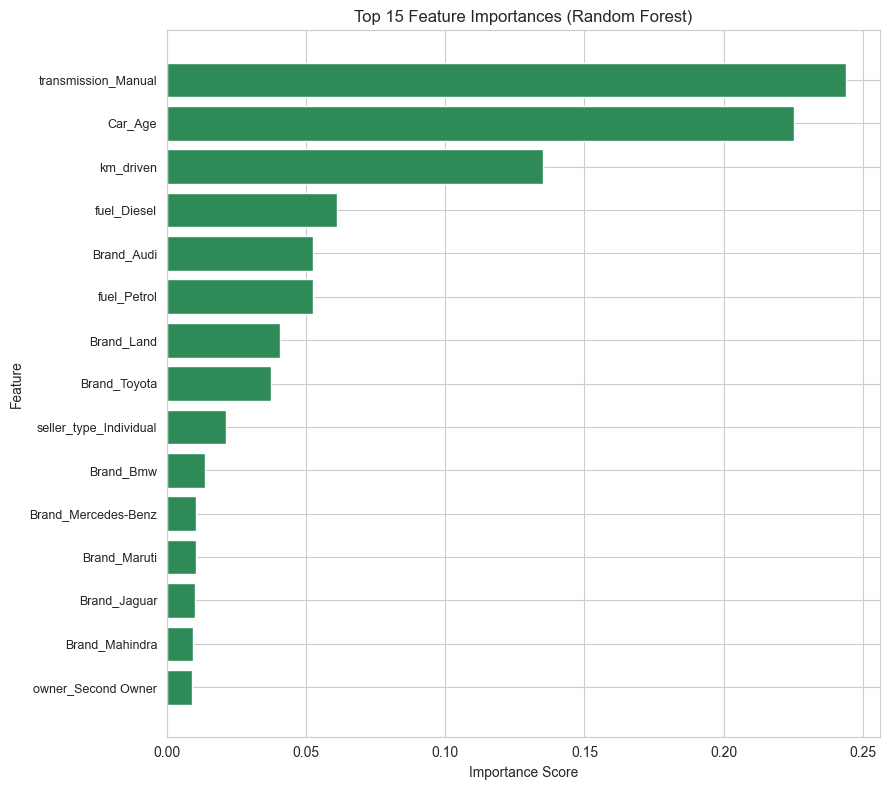

In [43]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance_df.head(15)
plt.figure(figsize=(9, 8))
plt.barh(top_features['Feature'], top_features['Importance'], color='seagreen')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.yticks(fontsize=9)
plt.savefig('ImpScore_Vs_Feature.png')
plt.tight_layout()
plt.show()

## Prediction Example

In [44]:
sample_index = 0
sample_features = X_test.iloc[[sample_index]]
actual_price = y_test.iloc[sample_index]
predicted_price = rf_model.predict(sample_features)[0]

print("Actual Selling Price:", round(actual_price, 2))
print("Predicted Selling Price:", round(predicted_price, 2))

Actual Selling Price: 270000
Predicted Selling Price: 568614.04
